In [1]:
# autoreload magic
%load_ext autoreload
%autoreload 2

In [2]:
BACKEND = "cpu"

In [3]:
from lisatools.globalfit.preprocessing import L1ProcessingStep
from lisatools.detector import L1Orbits
from lisatools.domains import STFTSettings
from lisatools.utils.utility import tukey
from lisatools.utils.constants import YRSID_SI

In [4]:
mojito_path = "/Volumes/as_storage/mojito/mojito_light_2p5s" if BACKEND == "cpu" else "/data/asantini/globalfit/MOJITO_DATA/mojito_light_2p5s/"

In [5]:
loader = L1ProcessingStep(
        L1_folder=mojito_path,
        source_types=["noise"],
        orbits_class=L1Orbits,
        orbits_kwargs=dict(force_backend="cpu", frame="icrs"),
        verbose=True,
    )

2026-10-02 16:44:58,361 - lisatools.globalfit.preprocessing - INFO - L1DataLoader initialized with data folder: /Volumes/as_storage/mojito/mojito_light_2p5s/data
2026-10-02 16:44:58,362 - lisatools.globalfit.preprocessing - INFO - Source types to load: ['NOISE']
2026-10-02 16:44:58,362 - lisatools.globalfit.preprocessing - INFO - Source IDs: None
2026-10-02 16:44:58,362 - lisatools.globalfit.preprocessing - INFO - Orbits class: L1Orbits
2026-10-02 16:44:58,363 - lisatools.globalfit.preprocessing - INFO - Orbits kwargs: {'force_backend': 'cpu', 'frame': 'icrs'}


[load_data] L1Orbits(...) (incl. _setup) took 40.31s
[load_data] orbits._ensure_configured() took 2.79s


2026-10-02 16:45:41,616 - lisatools.globalfit.preprocessing - INFO - Initialized orbits from NOISE file.


[load_data] NOISE f.tdis.xyz_doppler[:] took 18.23s shape=(25246480, 3)


2026-10-02 16:46:05,426 - lisatools.globalfit.preprocessing - INFO - Loaded NOISE data from /Volumes/as_storage/mojito/mojito_light_2p5s/data/INSTRUMENT/L1/NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5
2026-10-02 16:46:05,427 - lisatools.globalfit.preprocessing - INFO - data, times and orbits initialized from NOISE file.
2026-10-02 16:46:05,427 - lisatools.globalfit.preprocessing - INFO - TDI time step: 2.5 seconds
2026-10-02 16:46:05,427 - lisatools.globalfit.preprocessing - INFO - TDI sampling frequency: 0.4 Hz


In [6]:
dt = 5
downsample_kwargs = {
    "target_fs": 1 / dt,
    "window": ("kaiser", 5.0), 
}
preprocess_kwargs = dict(
        highpass_kwargs=dict(cutoff=5e-6, order=2, zero_phase=True),
        lowpass_kwargs=dict(cutoff=0.8 * downsample_kwargs['target_fs'], order=2, zero_phase=True),
        trim_kwargs=dict(
            duration=200 * 3600, is_percent=False, trimming_type="from_each_end"
        ),
        downsample_kwargs=downsample_kwargs,
        Tobs=2. * YRSID_SI
)

In [7]:
loader.process(**preprocess_kwargs)

2026-10-02 16:46:05,601 - lisatools.globalfit.preprocessing - INFO - Applying highpass filter...
2026-10-02 16:46:08,133 - lisatools.globalfit.preprocessing - INFO - Applying lowpass filter...
2026-10-02 16:46:10,392 - lisatools.globalfit.preprocessing - INFO - Downsampling data...
2026-10-02 16:46:11,496 - lisatools.globalfit.preprocessing - INFO - Updated parameters: N=12623240, T=63116195.000000015
2026-10-02 16:46:11,498 - lisatools.globalfit.preprocessing - INFO - Trimming data...
2026-10-02 16:46:11,498 - lisatools.globalfit.preprocessing - INFO - Trimming 720000s (144000 samples) from each end of the data.
2026-10-02 16:46:11,498 - lisatools.globalfit.preprocessing - INFO - Updated parameters: N=12335240, T=61676195.000000015
2026-10-02 16:46:11,498 - lisatools.globalfit.preprocessing - WARNING - Requested observation time Tobs=63116299.52709119s exceeds total data duration T=61676195.000000015s. No trimming applied.
2026-10-02 16:46:11,499 - lisatools.globalfit.preprocessing - 

(array([9.84499398e+07, 9.84499448e+07, 9.84499498e+07, ...,
        1.60126120e+08, 1.60126125e+08, 1.60126130e+08], shape=(12335239,)),
 array([[ 2.99324632e-21,  2.17721560e-20, -2.29735997e-20, ...,
          8.25956569e-21, -4.60640123e-21,  5.93815531e-21],
        [-1.71242899e-20,  2.87515496e-20, -7.75726537e-21, ...,
         -4.05550329e-20,  2.74767517e-21,  1.56631950e-20],
        [-5.41921045e-20,  4.97603814e-20, -1.43514794e-20, ...,
         -5.55315072e-21, -3.15748672e-22, -2.35928560e-21]],
       shape=(3, 12335239)))

In [8]:
DT = 7 * 24 * 3600  # day in seconds
TAPER = 600 * 2 # seconds
settings_factory = STFTSettings.make_factory(big_dt=DT, min_freq=1e-4)#, max_freq=1e-1)
settings_cpu = settings_factory(loader.times, loader.dt, "cpu")
settings = settings_factory(loader.times, loader.dt, BACKEND)

nperseg = settings_cpu.get_nperseg(loader.dt)
window = tukey(nperseg, alpha=TAPER / DT)
print(f"window length: {nperseg} samples, {nperseg * loader.dt:.2f} seconds")
print(f"window taper: {TAPER} seconds")
print(f"window parameter: {TAPER / DT}")

window length: 120960 samples, 604800.00 seconds
window taper: 1200 seconds
window parameter: 0.001984126984126984


In [9]:
data, orbits = loader.pour(settings=settings, window=window, return_orbits=True)

In [10]:
response = loader.get_total_response(settings_cpu.f_arr)

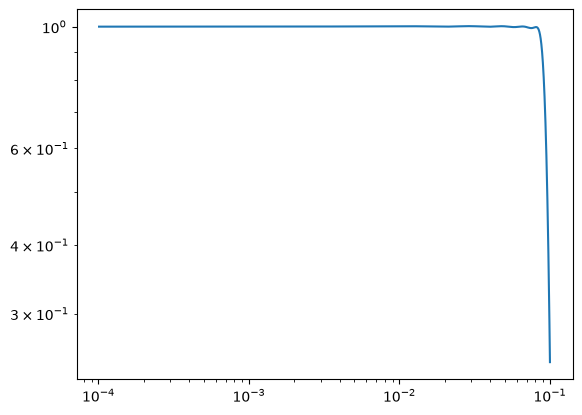

In [11]:
import matplotlib.pyplot as plt
plt.loglog(settings_cpu.f_arr, response)


In [12]:
def get_window_kernel(x):
    """Two-sided spectral window |W[k]|^2 / N^2 on the full DFT circle (length N)."""
    return len(x) * xp.real(xp.fft.ifft(x))

def convolve_matrix_components(c00, c11, c22, c01, c02, c12, window_values, num_psds: int = 1, active_slice=slice(None), chunk: int = 2**5):
    """Convolve one-sided PSD entries with the window's two-sided spectral window.

    ``entries`` may live on the active band only; they are embedded into the full
    one-sided grid (out-of-band PSD assumed zero), convolved on the full length-N
    circle, and sliced back. Pass the full grid whenever you can.
    """
    N = len(window_values)
    nf_full = N // 2 + 1
    start, stop, _ = active_slice.indices(nf_full)
    kt = get_window_kernel(window_values)
    out = []
    for c in (c00, c11, c22, c01, c02, c12):
        rows = c.reshape(-1, stop - start)
        if not bool(xp.isfinite(rows[:, 0]).all()):
            rows[:, 0] = rows[:, 1]
        for i in range(0, rows.shape[0], chunk):
            r = rows[i:i + chunk]
            full = xp.empty((r.shape[0], nf_full), dtype=xp.complex128)
            full[:, :start] = r[:, :1]
            full[:, start:stop] = r
            full[:, stop:] = r[:, -1:]
            ts = xp.fft.irfft(full, n=N, axis=-1)
            del full
            ts *= kt
            conv = xp.fft.rfft(ts, axis=-1)[:, start:stop]
            del ts
            r[...] = conv if xp.iscomplexobj(r) else conv.real
            del conv
        out.append(c.reshape(num_psds, -1))
    return out


In [13]:
from lisatools.sensitivity import XYZSensitivityBackend, SensitivityMatrixBase
import numpy as np
if BACKEND == "gpu":
    import cupy as xp
else:
    xp = np

In [14]:
orbits.kwargs

{'armlength': 2500000000.0,
 'force_backend': 'cpu',
 'frame': 'icrs',
 'linear_interp_dt': 500.0}

In [20]:
_kwargs = orbits.kwargs.copy()
_kwargs.update({'force_backend': BACKEND})
_kwargs['linear_interp_setup'] = True
orbits = orbits.__class__(*orbits.args, **_kwargs)

In [55]:
sens_backend = XYZSensitivityBackend(orbits, settings=settings, window_values=window, force_backend=BACKEND)
sens_backend_no_norm = XYZSensitivityBackend(orbits, settings=settings, window_values=None,  filters_response=response, force_backend=BACKEND)
sens_backend_convolve = XYZSensitivityBackend(orbits, settings=settings, window_values=window, convolve_window=True, filters_response=response, mask_percentage=0.0, smoothing_sigma=0, force_backend=BACKEND)

In [56]:
sens_backend_convolve.fft_batch_size

16

In [57]:
from lisatools.analysiscontainer import AnalysisContainer

In [58]:
assert isinstance(sens_backend, SensitivityMatrixBase)

In [59]:
sens_backend_convolve.set_sensitivity_matrix()

ac = AnalysisContainer(
    data=data, sens_mat=sens_backend_convolve
)

In [60]:
print(sens_backend.noise_normalization)
print(sens_backend_no_norm.noise_normalization)
print(sens_backend_convolve.noise_normalization)

[0.99875165 0.99875165 0.99875165 ... 0.99875165 0.99875165 0.99875165]
[0.99998848 0.99998926 0.99998998 ... 0.24494973 0.24486092 0.24477212]
[0.99998848 0.99998926 0.99998998 ... 0.24494973 0.24486092 0.24477212]


In [77]:
sens_mat_smooth = sens_backend.compute_sensitivity_matrix( smooth=True)
sens_mat = sens_backend.compute_sensitivity_matrix( smooth=False)
sens_mat_no_norm = sens_backend_no_norm.compute_sensitivity_matrix( smooth=False)

In [62]:
sens_mat_convolved = sens_backend_convolve.compute_sensitivity_matrix( smooth=False)

In [78]:
c_00, c_11, c_22, c_01, c_02, c_12 = sens_mat_no_norm[0, 0].copy(), sens_mat_no_norm[1, 1].copy(), sens_mat_no_norm[2, 2].copy(), sens_mat_no_norm[0, 1].copy(), sens_mat_no_norm[0, 2].copy(), sens_mat_no_norm[1, 2].copy()

In [79]:
manually_convolved = convolve_matrix_components(c_00, c_11, c_22, c_01, c_02, c_12, window_values=window, num_psds=1, active_slice=settings.active_slice, chunk=2**5)

In [80]:
manually_convolved_matrix = xp.zeros_like(sens_mat_no_norm)
manually_convolved_matrix[0, 0] = manually_convolved[0].reshape(settings.basis_shape_active)
manually_convolved_matrix[1, 1] = manually_convolved[1].reshape(settings.basis_shape_active)
manually_convolved_matrix[2, 2] = manually_convolved[2].reshape(settings.basis_shape_active)
manually_convolved_matrix[0, 1] = manually_convolved[3].reshape(settings.basis_shape_active)
manually_convolved_matrix[0, 2] = manually_convolved[4].reshape(settings.basis_shape_active)
manually_convolved_matrix[1, 2] = manually_convolved[5].reshape(settings.basis_shape_active)
manually_convolved_matrix[1, 0] = manually_convolved[3].conj().reshape(settings.basis_shape_active)
manually_convolved_matrix[2, 0] = manually_convolved[4].conj().reshape(settings.basis_shape_active)
manually_convolved_matrix[2, 1] = manually_convolved[5].conj().reshape(settings.basis_shape_active)

In [66]:
manually_convolved_matrix

array([[[[5.50471414e-34-7.20506681e-53j,
          5.50471414e-34-1.11628398e-52j,
          5.50471414e-34-1.97657147e-53j, ...,
          5.49420825e-34+4.86708369e-53j,
          5.49420830e-34+3.32230154e-53j,
          5.49420832e-34+0.00000000e+00j],
         [5.50757658e-34+6.02957745e-53j,
          5.50757658e-34+1.00940444e-52j,
          5.50757658e-34+8.57133216e-54j, ...,
          5.49702463e-34-1.42875970e-53j,
          5.49702468e-34-6.02330577e-56j,
          5.49702470e-34+0.00000000e+00j],
         [5.51064382e-34-1.43293140e-53j,
          5.51064382e-34+1.89004619e-53j,
          5.51064382e-34+3.35722608e-53j, ...,
          5.50004533e-34-1.43541099e-53j,
          5.50004539e-34+5.04819978e-53j,
          5.50004540e-34+0.00000000e+00j],
         ...,
         [5.53763070e-34-6.55931985e-53j,
          5.53763070e-34+4.94620421e-53j,
          5.53763070e-34+1.00463166e-53j, ...,
          5.52671178e-34+7.99845189e-54j,
          5.52671184e-34+3.84267002e-53

In [67]:
import time

In [68]:
def synchronize(xp):
    if xp.__name__ == "cupy":
        xp.cuda.Stream.null.synchronize()

def get(arr):
    if hasattr(arr, "get"):
        return arr.get()
    return arr

In [69]:
tic = time.time()
_ = sens_backend.compute_sensitivity_matrix( smooth=False)
synchronize(xp)
toc = time.time()

print(f"Time taken to compute sensitivity matrix without convolution on {BACKEND}: {toc - tic:.5f} seconds")

tic = time.time()
_ = sens_backend_convolve.compute_sensitivity_matrix( smooth=False)
synchronize(xp)
toc = time.time()

print(f"Time taken to compute sensitivity matrix with convolution on {BACKEND}: {toc - tic:.5f} seconds")

Time taken to compute sensitivity matrix without convolution on cpu: 6.74638 seconds
Time taken to compute sensitivity matrix with convolution on cpu: 18.57437 seconds


In [70]:
tf_periodogram = np.einsum('itf,jtf->ijtf', data.arr, np.conj(data.arr)) * 2 * settings.df

In [71]:

try:
    from cantuccio.visuals import get_paper_style
    style = get_paper_style()
    plt.style.use(style)
except (ImportError, ModuleNotFoundError):
    pass

In [72]:
get_window_kernel(window)

array([120839.        ,   -120.99968947,   -120.99875788, ...,
         -120.99720524,   -120.99875788,   -120.99968947], shape=(120960,))

In [73]:
np.fft.fft(window)

array([120839.        +0.j        ,   -120.99968947-0.00314262j,
         -120.99875788-0.0062852j , ...,   -120.99720524+0.00942768j,
         -120.99875788+0.0062852j ,   -120.99968947+0.00314262j],
      shape=(120960,))

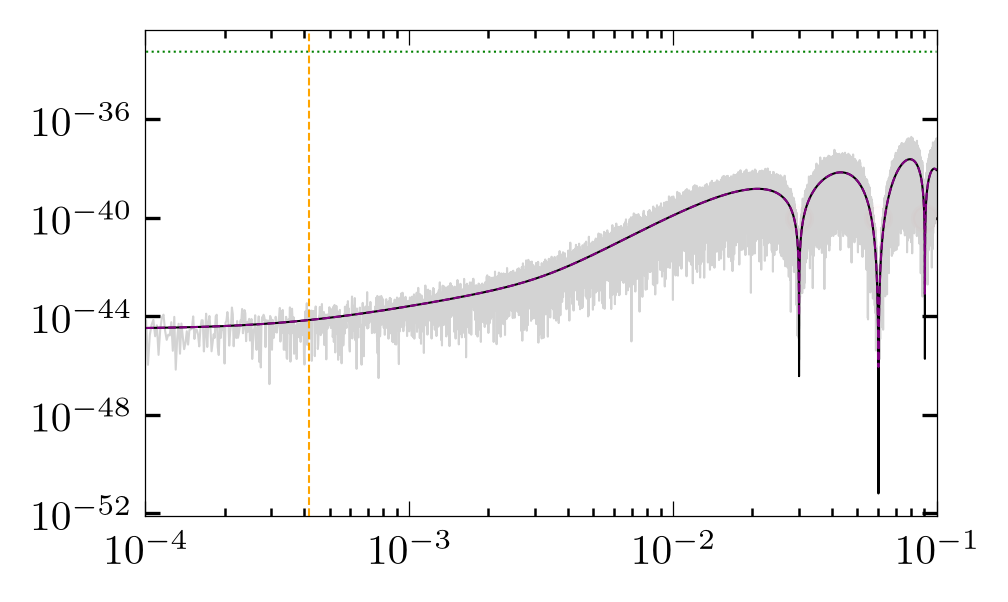

In [82]:
plt.figure()

ch0, ch1 = 0, 0
time_bin = 0
mask = sens_backend_convolve.dips_mask.reshape(sens_backend_convolve.basis_settings.basis_shape)
dips_frequencies = get(settings.f_arr[mask[time_bin]])

plt.loglog(get(data.settings.f_arr), np.abs(get(tf_periodogram[ch0, ch1, time_bin, :])), label="X", c='lightgrey')
plt.loglog(get(data.settings.f_arr), np.abs(get(sens_mat_no_norm[ch0, ch1, time_bin, :])), label="unnormalized sensitivity", c='k')
#plt.loglog(get(data.settings.f_arr), np.abs(get(sens_mat[ch0, ch1, time_bin, :])), label="X sensitivity", c='blue')
# plt.loglog(get(data.settings.f_arr), np.abs(get(sens_mat[ch0, ch1, time_bin, :]) * response), label="filtered sensitivity", c='red', ls='--')
# plt.loglog(get(data.settings.f_arr), np.abs(get(sens_mat_smooth[ch0, ch1, time_bin, :]) * response), label="smoothed filtered sensitivity", c='green', ls='-.')
plt.loglog(get(data.settings.f_arr), np.abs(get(sens_mat_convolved[ch0, ch1, time_bin, :])), label="convolved filtered sensitivity", c='purple', ls='--')
plt.loglog(get(data.settings.f_arr), np.abs(get(manually_convolved_matrix[ch0, ch1, time_bin, :])), label="RFFT convolved filtered sensitivity", c='green', ls=':')
#plt.loglog(get(data.settings.f_arr), np.abs(get(ac.sens_mat.sens_mat[ch0, ch1, time_bin, :])), label="convolved filtered sensitivity", c='k', ls='--')

# plot the dips mask
plt.scatter(dips_frequencies, np.ones_like(dips_frequencies) * 1e-40, marker='o', color='red', alpha=0.01, label="dips mask", zorder=10)

# plot the vertical line matching the roll-off frequency of the window

plt.axvline(x=1/(2*TAPER), color='orange', ls='--', label="window roll-off frequency")

plt.xlim(1e-4, 1e-1)
#plt.xlim(2.95e-2, 3.05e-2)
#plt.xlim(8.5e-2, 1e-1)
#plt.ylim(1e-44, 1e-37)
plt.show()

/Users/alessandrosantini/reps/globalift/erebor_org_setup/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/alessandrosantini/reps/globalift/erebor_org_setup/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


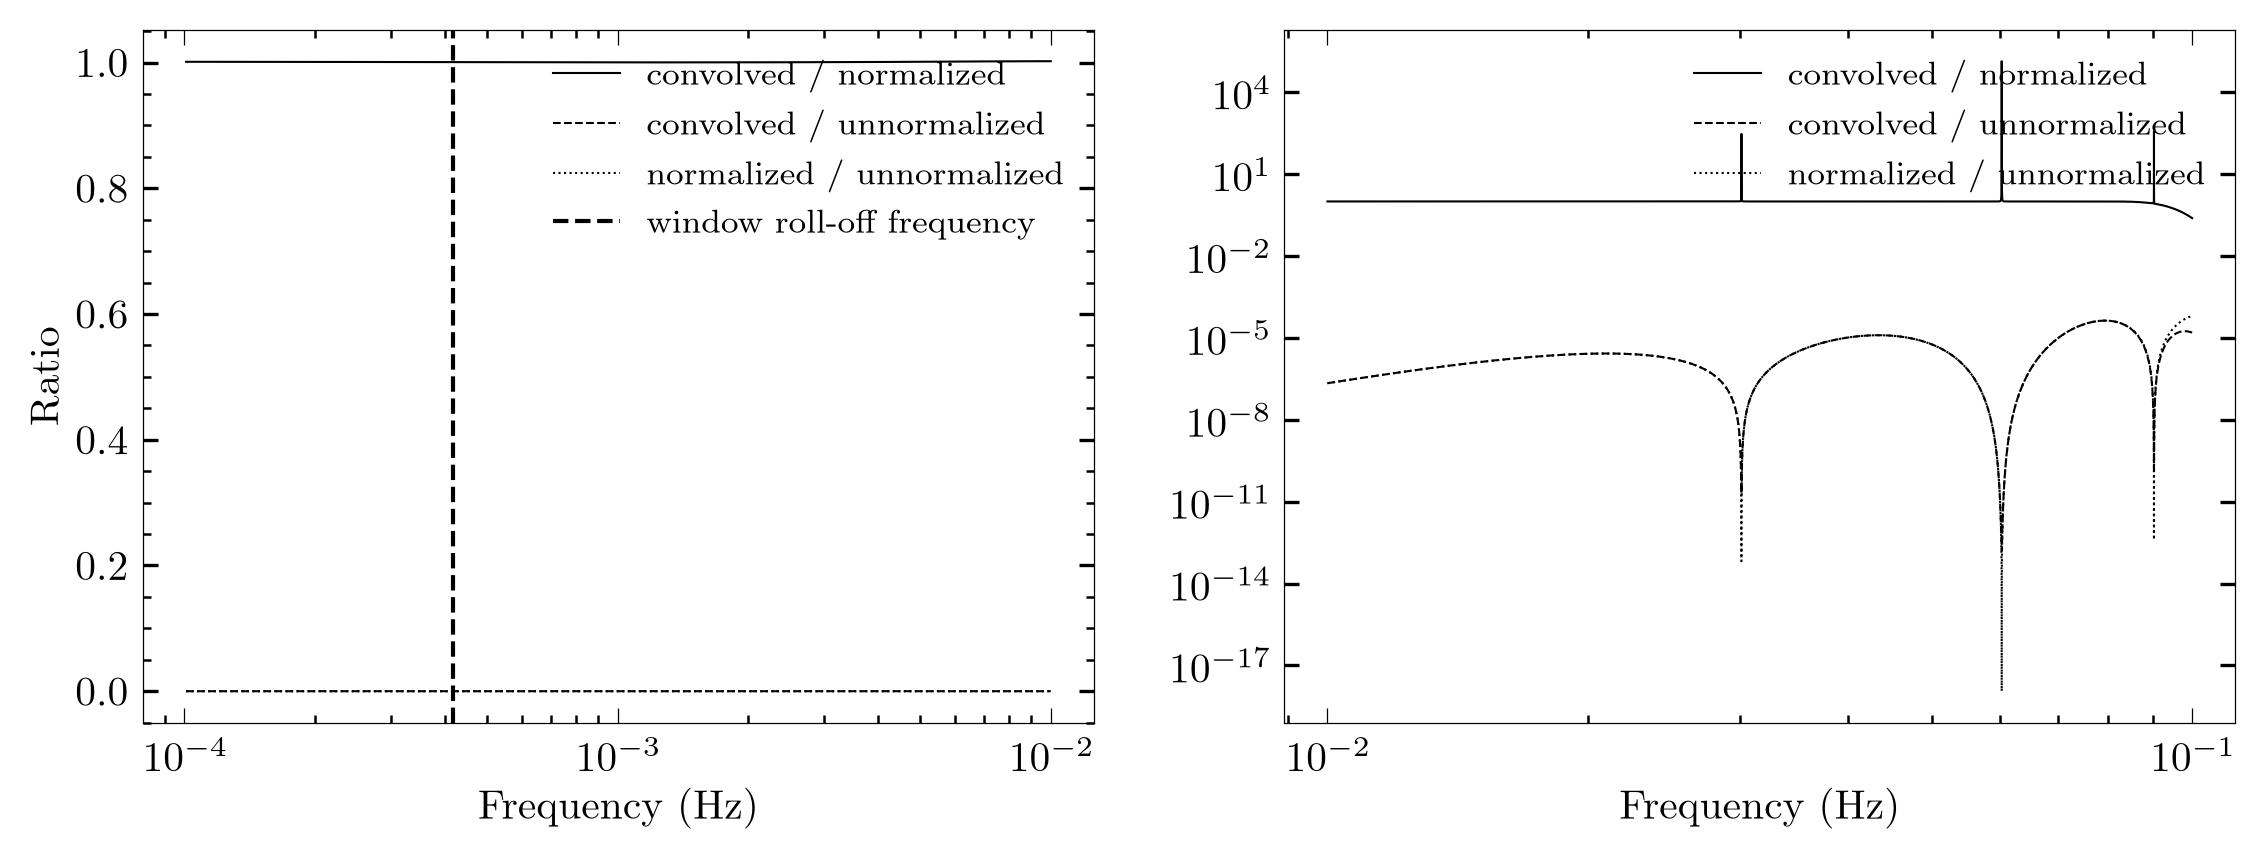

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3))

ranges = [(1e-4, 1e-2), (1e-2, 1e-1)]

for i, (ax, freq_range) in enumerate(zip(axs, ranges)):
    mask = (data.settings.f_arr >= freq_range[0]) & (data.settings.f_arr <= freq_range[1])
    ax.semilogx(get(data.settings.f_arr[mask]), get((sens_mat_convolved[ch0, ch1, time_bin, :] / sens_mat[ch0, ch1, time_bin, :])[mask]), label="convolved / normalized", c='k', ls='-')
    ax.semilogx(get(data.settings.f_arr[mask]), get((sens_mat_convolved[ch0, ch1, time_bin, :] / sens_mat_no_norm[ch0, ch1, time_bin, :])[mask]), label="convolved / unnormalized", c='k', ls='--')
    ax.semilogx(get(data.settings.f_arr[mask]), get((sens_mat[ch0, ch1, time_bin, :] / sens_mat_no_norm[ch0, ch1, time_bin, :])[mask]), label="normalized / unnormalized", c='k', ls=':')

    if 1/(2*TAPER) >= freq_range[0] and 1/(2*TAPER) <= freq_range[1]:
        f_taper = 1/(2*TAPER)
        ax.axvline(x=f_taper, color='k', lw=1, ls='--', label="window roll-off frequency")

    ax.legend()
    ax.set_xlabel('Frequency (Hz)')

axs[0].set_ylabel('Ratio')
axs[1].set_yscale('log')

## check the likelihood

In [97]:
NUM_WALKERS = 3

S_oms = xp.array([15e-12] * NUM_WALKERS) * xp.random.uniform(0.9, 1.1, size=NUM_WALKERS)
S_acc = xp.array([3e-15] * NUM_WALKERS) * xp.random.uniform(0.9, 1.1, size=NUM_WALKERS)
Amp = alpha = f_1 = f_kn = f_2 = xp.array([0.0] * NUM_WALKERS)
data_index = xp.arange(NUM_WALKERS, dtype=np.int32)

data_ll = xp.array([data.arr.copy() for _ in range(NUM_WALKERS)])

In [101]:
tic = time.time()
ll = sens_backend_convolve.compute_log_like(data_ll, data_index, S_oms, S_acc, Amp, alpha, f_1, f_kn, f_2)
synchronize(xp)
toc = time.time()

print(f"Time taken to compute {NUM_WALKERS} log-likelihood with convolution on {BACKEND}: {toc - tic:.5f} seconds")   

Time taken to compute 3 log-likelihood with convolution on gpu: 0.09818 seconds


In [99]:
tic = time.time()
sens_backend_convolve.compute_log_like(data_ll, data_index, S_oms, S_acc, Amp, alpha, f_1, f_kn, f_2, convolve_window=False)
synchronize(xp)
toc = time.time()

print(f"Time taken to compute {NUM_WALKERS} log-likelihood without convolution on {BACKEND}: {toc - tic:.5f} seconds")

Time taken to compute 3 log-likelihood without convolution on gpu: 0.02040 seconds


In [103]:
ac.sens_mat.set_sensitivity_matrix(S_oms[0].item(), S_acc[0].item())

(ac.likelihood() - ll[0]) / ac.likelihood()

array(-1.8568753e-05)

In [ ]:
from lisatools.analysiscontainer import AnalysisContainer

In [ ]:
ac = AnalysisContainer(data=data, sens_mat=sens_backend_convolve)

In [ ]:
import lisatools
isinstance(sens_backend, lisatools.sensitivity.SensitivityMatrixBase)

### Frequency-frequency matrix of the data_channel

In [ ]:
channel = 0

# One segment's outer product d d^H is rank-1: |d_k||d_k'| everywhere, so it has no
# diagonal structure by construction. The frequency-frequency covariance is an
# expectation, so average the outer product over the STFT time segments.
d = data.arr[channel]          # (NT, NF)
NT, NF = d.shape
print(f"{NT} segments x {NF} frequency bins")

In [ ]:
# Banded estimate of C[k, k+q] = <d_k conj(d_{k+q})>_t for lags q = 0..B (full NF x NF is 1.2 GB
# and everything beyond a few tens of bins is noise).
B = 500
C_band = np.zeros((B + 1, NF), dtype=complex)
for q in range(B + 1):
    C_band[q, : NF - q] = np.mean(d[:, : NF - q] * np.conj(d[:, q:]), axis=0)

# correlation coefficient per lag. C[k,k+q] ~ S[k] conj(V[q]) / N has the same phase at every k
# (smooth PSD), so average the normalised complex value over bins coherently: the 1/sqrt(NT)
# estimation noise then averages down by a further 1/sqrt(n_bins) instead of adding in quadrature.
f = data.settings.f_arr
smooth = (f > 1e-3) & (f < 2e-2)          # away from DC and the TDI notches
C0 = np.real(C_band[0])
rho_meas = np.array([
    np.abs(np.mean((C_band[q, : NF - q] / np.sqrt(C0[: NF - q] * C0[q:]))[smooth[: NF - q]]))
    for q in range(B + 1)
])

# prediction from the window alone (smooth PSD): C[k, k+q] ~ S[k] V[q] / N with V = fft(w^2)
V = np.fft.fft(window ** 2)
rho_pred = np.abs(V[: B + 1]) / V[0].real
noise_floor = 1 / np.sqrt(NT * smooth.sum())   # coherent-average noise floor on rho_meas
elem_floor = 1 / np.sqrt(NT)                    # noise on a single matrix element (block image below)
print("lag  rho_meas  rho_pred")
for q in range(6):
    print(f"{q:3d}   {rho_meas[q]:.4f}    {rho_pred[q]:.4f}")
print(f"noise floor: {noise_floor:.4f} on rho_meas, {elem_floor:.3f} per matrix element")

In [ ]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.5))

# |rho| vs lag: measured against the window prediction
lags = np.arange(B + 1)
ax0.semilogy(lags, rho_meas, "o", label="measured  |C[k,k+q]| / sqrt(C[k,k] C[k+q,k+q])")
ax0.semilogy(lags, rho_pred, "-", label="window prediction  |fft($w^2$)[q]| / sum($w^2$)")
ax0.axhline(noise_floor, ls="--", c="grey", label="noise floor of the estimate")
ax0.set_xlabel("lag q (bins)"); ax0.set_ylabel(r"$|\rho_q|$"); ax0.set_ylim(1e-3, 2); ax0.legend(fontsize=8)

# a zoomed block of the normalised covariance, linear frequency axes
k0 = int(3e-3 / data.settings.df); nb = B
block = np.mean(d[:, k0 : k0 + nb, None] * np.conj(d[:, None, k0 : k0 + nb]), axis=0)
diag = np.real(np.diag(block))
corr = np.abs(block) / np.sqrt(np.outer(diag, diag))
ext = [f[k0], f[k0 + nb - 1], f[k0], f[k0 + nb - 1]]
from matplotlib.colors import LogNorm
im = ax1.imshow(corr, origin="lower", extent=ext, norm=LogNorm(vmin=1e-2, vmax=1), cmap="cividis")
ax1.set_xlabel("Frequency (Hz)"); ax1.set_ylabel("Frequency (Hz)")
ax1.set_title(f"|corr| block, {nb} bins at {f[k0]:.2e} Hz  (single-element noise ~{elem_floor:.2f})")
fig.colorbar(im, ax=ax1)

plt.show()